In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### Load LLM

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1"
)

llm.invoke("Whats your name")

AIMessage(content="I'm called ChatGPT! How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 10, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlaBz1nAAdMcHl1pjsgdyD7JcxZQS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--03a1a3bd-657f-4c4f-9c34-0079ae8f2a99-0', usage_metadata={'input_tokens': 10, 'output_tokens': 12, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### MULTI - AGENT Dummy

In [3]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

In [4]:
def add_number(state):
    result=state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply",update={"sum":result})

In [5]:
state={"num1":10,"num2":20}

In [6]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

In [7]:
from langchain_core.tools import tool

In [8]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [9]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [17]:
llm_with_tool=llm.bind_tools([transfer_to_addition_expert])

In [18]:
response=llm_with_tool.invoke("hi")

In [19]:
response.content


'Hello! How can I help you today? 😊'

In [20]:
response.tool_calls

[]

In [24]:
response=llm_with_tool.invoke("what is 2 + 2?")

response.content, response.tool_calls

('2 + 2 = 4.', [])

In [25]:
system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [26]:
messages = [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [27]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [28]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [29]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [30]:
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

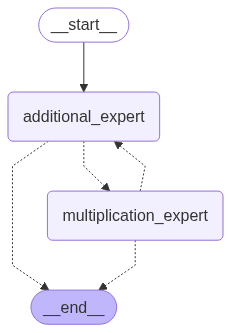

In [31]:
graph=StateGraph(MessagesState)

graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

graph.add_edge(START, "additional_expert")

app=graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='ed9d58ed-84b6-4fe9-879b-0e749e6227c0'),
  AIMessage(content="First, I'll calculate the addition part:\n\n3 + 5 = 8\n\nNow, I'll need help from the multiplication expert to calculate 8 * 12.", additional_kwargs={'tool_calls': [{'id': 'call_vA8xKvgcPwjb1RjBmCf2Bu80', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 86, 'total_tokens': 135, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-Blc5y15YDaAQcrTBSS9HhFhxAc0Ix', 'service_tier': 'default', 'finish_reason': 'tool_calls'

### Realtime Multi-agent

In [33]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
search_tool.invoke("What is the capital of France?")

'Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most important and attractive cities, famed for its gastronomy, haute couture, painting, literature, and intellectual community. Learn more about Paris in this article. Paris (French pronunciation: [paʁi] ) is the capital and largest city of France. With an estimated population of 2,048,472 residents in January 2025 in an area of more than 105 km2 (41 sq mi), Paris is the fourth-most populous city in the European Union and the 30th most densely populated city in the world in 2022. France: The capital of France is Paris. Paris is not only the political capital but also a major cultural and economic center. It is famous for landmarks such as the Eiffel Tower, Notre-Dame Cathedral, and the Louvre Museum. Germany: The capital of Germany is Berlin. Berlin is known for its rich history and cultural significance, including the ... France\'s capital city lie

In [34]:
from langchain_experimental.utilities import PythonREPL

In [37]:
repl = PythonREPL()

In [38]:
code = """
x = 10
y = 20
result = x + y
print(result)
"""

In [39]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'30\n'

In [40]:
from typing import Annotated

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."]
):
    """Use this to excecute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Error: {e}"
    
    result_str = f"Successfully executed code. \n\`\`\`python\n{code}\n\`\`\`\nOutput:\n```\n{result}\n```"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER"
    )

In [42]:
print(python_repl_tool.invoke(
    "x = 10\ny = 20\nresult = x + y\nprint(result)"
))

Successfully executed code. 
\`\`\`python
x = 10
y = 20
result = x + y
print(result)
\`\`\`
Output:
```
30

```

If you have completed all tasks, respond with FINAL ANSWER


In [52]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [53]:
make_system_prompt("What is the capital of France?")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nWhat is the capital of France?"

In [54]:
from langchain_core.messages import BaseMessage, HumanMessage

def get_next_node(last_message: BaseMessage, goto: str) -> str:
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [68]:
from langgraph.graph import MessagesState, StateGraph, START, END


# Agent 1
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    research_agent = create_react_agent(
        llm,
        tools=[search_tool],
        prompt = make_system_prompt("You can only do research. \
            You are working with a chart generator colleague."),
    )
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    return Command(
        goto=goto,
        update={"messages": result["messages"]},
    )

In [69]:
# Agent 2
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    chart_agent = create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt = make_system_prompt("You can only generate chart. \
            You are working with a researcher colleague."),
    )
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(
        goto=goto,
        update={"messages": result["messages"]}
    )

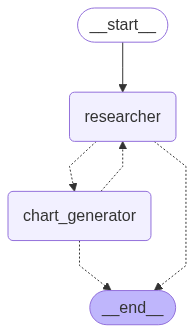

In [70]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

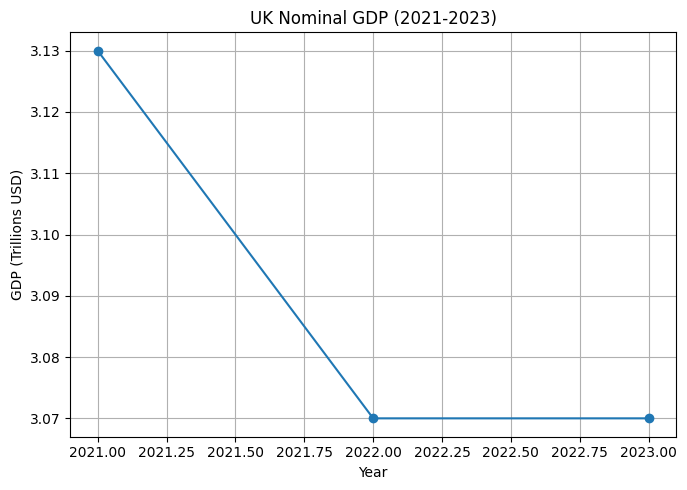

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='3f1237c7-2bcb-4d7a-a299-7a9c9efe10e3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_bAFhc91xrQK6diQg2GkzLFGp', 'function': {'arguments': '{"query":"UK GDP for the past 3 years"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 200, 'total_tokens': 224, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlzWr6OkfPI9eABzxEjE5ORRaWnrG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b8000b62-f191-465

In [73]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})